Import Dataset

In [33]:
import pandas as pd

df = pd.read_csv('heart_disease_uci.csv')

In [34]:
df.shape

(920, 16)

In [35]:
df.head(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


Need to clean dataset.  First we will drop the id row. Second, drop any rows that have missing information. Then we will set up a schema to turn all values that are string into integers.

In [36]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')

In [37]:
#drop ID row can append more drops later
drop_columns = ['id']
cleaned_df = df.drop(columns=drop_columns)

cleaned_df.head(10)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [38]:
# #create iterable process for turning values numerical
# values = set([value for value in cleaned_df['sex']])

# targets = [target[0] for target in enumerate(values)]

# cleaned_df['sex'].replace(values, targets)



In [39]:
for col in cleaned_df.columns:
    if cleaned_df[col].dtype != int and cleaned_df[col].dtype != float:
        print(f'foundone {cleaned_df[col]}')
        values = set([value for value in cleaned_df[col]])

        targets = [target[0] for target in enumerate(values)]

        cleaned_df[col] = cleaned_df[col].replace(values, targets)

        print(f'switched {cleaned_df[col]}')



foundone 0        Male
1        Male
2        Male
3        Male
4      Female
        ...  
915    Female
916      Male
917      Male
918      Male
919      Male
Name: sex, Length: 920, dtype: str
switched 0      0
1      0
2      0
3      0
4      1
      ..
915    1
916    0
917    0
918    0
919    0
Name: sex, Length: 920, dtype: object
foundone 0          Cleveland
1          Cleveland
2          Cleveland
3          Cleveland
4          Cleveland
           ...      
915    VA Long Beach
916    VA Long Beach
917    VA Long Beach
918    VA Long Beach
919    VA Long Beach
Name: dataset, Length: 920, dtype: str
switched 0      0
1      0
2      0
3      0
4      0
      ..
915    2
916    2
917    2
918    2
919    2
Name: dataset, Length: 920, dtype: object
foundone 0       typical angina
1         asymptomatic
2         asymptomatic
3          non-anginal
4      atypical angina
            ...       
915       asymptomatic
916     typical angina
917       asymptomatic
918       a

In [40]:
cleaned_df.head(10)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,0,0,3,145.0,233.0,1,0,150.0,0,2.3,1,0.0,0,0
1,67,0,0,0,160.0,286.0,0,0,108.0,1,1.5,0,3.0,2,2
2,67,0,0,0,120.0,229.0,0,0,129.0,1,2.6,0,2.0,1,1
3,37,0,0,1,130.0,250.0,0,1,187.0,0,3.5,1,0.0,2,0
4,41,1,0,2,130.0,204.0,0,0,172.0,0,1.4,3,0.0,2,0
5,56,0,0,2,120.0,236.0,0,1,178.0,0,0.8,3,0.0,2,0
6,62,1,0,0,140.0,268.0,0,0,160.0,0,3.6,1,2.0,2,3
7,57,1,0,0,120.0,354.0,0,1,163.0,1,0.6,3,0.0,2,0
8,63,0,0,0,130.0,254.0,0,0,147.0,0,1.4,0,1.0,1,2
9,53,0,0,0,140.0,203.0,1,0,155.0,1,3.1,1,0.0,1,1


Create features and labels

In [41]:
X = cleaned_df.drop(columns = ['num'])
X= X.fillna(X.median(numeric_only=True))

X.head(10)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,0,0,3,145.0,233.0,1,0,150.0,0,2.3,1,0.0,0
1,67,0,0,0,160.0,286.0,0,0,108.0,1,1.5,0,3.0,2
2,67,0,0,0,120.0,229.0,0,0,129.0,1,2.6,0,2.0,1
3,37,0,0,1,130.0,250.0,0,1,187.0,0,3.5,1,0.0,2
4,41,1,0,2,130.0,204.0,0,0,172.0,0,1.4,3,0.0,2
5,56,0,0,2,120.0,236.0,0,1,178.0,0,0.8,3,0.0,2
6,62,1,0,0,140.0,268.0,0,0,160.0,0,3.6,1,2.0,2
7,57,1,0,0,120.0,354.0,0,1,163.0,1,0.6,3,0.0,2
8,63,0,0,0,130.0,254.0,0,0,147.0,0,1.4,0,1.0,1
9,53,0,0,0,140.0,203.0,1,0,155.0,1,3.1,1,0.0,1


In [42]:
X.shape

(920, 14)

In [43]:
y = (cleaned_df['num']>0).astype(int)

split train, dev, and test. This was kind of tricky to realize what was going on.

The first split stores 60% of the data in X_train and y_train, then carries the last 40% into the next split with x_temp, y_temp. this carryover is then split in half to develop dev and test.

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.40, stratify=y, random_state=42
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.50, stratify=y_temp, random_state=42
)

In [45]:
# track metrics

from sklearn.metrics import classification_report, confusion_matrix

Now I need to choose some models from sklearn.:

KNNClassifier: 

KNN creates a datapoint and plots it against datapoints in the models training set. It then measures the distance between the nearest (k) data points and determines which classified neighbors hold the majority. It then classifies the data point as it's technically nearest neighbors. KNN is fairly unique in a sense that it doesn't actually store an internal model but instead just runs calculations on the current data point against the plotted training set.

Linear Discriminant Analysis Classifier: 

A LDA classifier aims to draw a linear boundary between classes. It does this by first taking the data points and grouping them based on their average feature vectors.

Next, it measures how far spread out the each point is within its own group creating a Within class Scatter Matrix. Ideally the scatter matrix is very small which will indicate that each group is distinct without much scatter.

Then the algorithm calculates how far the groups are away from each other. This Between Class Scatter Matrix is created by measuring the distance between the average centers of each group. We want the matrix to be very large indicating that the group are disinctly far away from each other. 

Finally the Algorithm uses fisher's score to determine which angle of projection provides the most distinct view of the groups, from there a single line is drawn at that angle and allthe points from each group are projected onto that line drawn through the groups best distinction. From here it is simple to create a simple threshold between the two groups and a simple way to provide distinction given the new data points representation on this linear representation of the 2 classes.

GaussianNB: 

The basic premise of the Naive Bayes algorithms is the assumption that all features are inedependent of each other. While this is completely unrealisticm mathematically it turns out that if you tally up the probabilities that each variable corresponds to the target.

The GaussianNB works by creating a normal distribution of each feature in relation to the label to determine the likelihood that that feature signals the corresponding label. Adding more features transforms the distributions into multidimensional hypserspace mountiains whose peaks are highest when the combinations signal the label the most. 

It then multiplies all the probabilities together to determine if the label will signal. It's simplicity makes it highly efficient and fast. Unforunately it also brings into account features that could be completely unrelated to the label and mutliplies them in at the same weight of highly correlated features.

DecisionTreeClassifier:

A decision tree classifier is basically exactly as it sounds. It start with a root node and builds out branches based on thresholds for each feature value. At the end there is a leaf node which is the classification output of the model. The trick with the tree is balancing it's size. If there tree is grown too large it will overfit the data and not generalize to new data points.

SVC:

SVC looks for the best possible line to seperate classes of data. In multidemensional space it creates a hyperplane that seperates the data points, this arises when you hve multiple features mapped onto a single datapoint. 

To create the hyperplane it tries to create the widest possible margin between the 2 classses in the hyperspace. It looks at the boundary points in which the two classes are closest to each other and uses them as support vectors for the boundaries.

From the support vectors it calculatues the distance between oppoipsing support vectors and determines the absolute center of and creates a hyperplane between the two classes.

New points are mapped into this hyperspace and are found to be on one side or the other of the hyperplane dividing the classes. 

In real world data we find that things are often not as clear cut. To remedy this SVC has a hyperparamter called the Slack Variable or "C". This parameter determines how loose the definition of boundary variables can be when defining the street. Low C leads to a wide street because some data points a deliberately misclassified in order to widen the margin to develop the hyperplane, while a High C allows the model to bend a narrow the street to highly attune it to the dataset.

In addition to the Slack Variable, SVC also allows for the Kernel Trick. In completely entangled data in it's mapped space it may be impossible to seperate one data from another. To differentiate the data it is possible to lift the points into a higher dimensional space to seperate data points from each other based on computations against their current features. These higher dimensional attributes serve to differentiate the entangled components. Computationally this could be a very bad solution, given large datasets it would be computationally instense to lift all of these points into higher dimensional space and remap them, the "Kernal Trick" instead uses a mathematical Kernel to calculate what the exact similarity would be between the two data points if they were both Actually lifted into their higher dimensional space.















Baseline models:

Majority Class Prediction

Random Prediction

In [46]:
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn import svm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [47]:
dummy_majority = Pipeline([
    ('scale', StandardScaler()),
    ('dummy_majority', DummyClassifier(strategy="most_frequent")),
])
dummy_majority.fit(X_train, y_train)

dev_pred = dummy_majority.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/Dummy/Dummy_majority.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")

print('Dev-set performance for Dummy Most Frequent:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for Dummy Most Frequent:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        82
           1      0.554     1.000     0.713       102

    accuracy                          0.554       184
   macro avg      0.277     0.500     0.357       184
weighted avg      0.307     0.554     0.395       184

Confusion matrix (rows=true, cols=pred):
[[  0  82]
 [  0 102]]


c:\Users\yzrd25\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yzrd25\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yzrd25\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [48]:
dummy_random = Pipeline([
    ('scale', StandardScaler()),
    ('dummy_random', DummyClassifier(strategy="stratified", random_state=42)),
])
dummy_random.fit(X_train, y_train)

dev_pred = dummy_random.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/Dummy/Dummy_random.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")
    
print('Dev-set performance for Dummy Most Frequent:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for Dummy Most Frequent:
              precision    recall  f1-score   support

           0      0.459     0.415     0.436        82
           1      0.564     0.608     0.585       102

    accuracy                          0.522       184
   macro avg      0.512     0.511     0.510       184
weighted avg      0.517     0.522     0.518       184

Confusion matrix (rows=true, cols=pred):
[[34 48]
 [40 62]]


KNN HyperParameters

knn = 5,10,15

In [49]:
knn_five = Pipeline([
    ('scale', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
])
knn_five.fit(X_train, y_train)

dev_pred = knn_five.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/KNN/knn_5.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")

print('Dev-set performance for k=5:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for k=5:
              precision    recall  f1-score   support

           0      0.773     0.829     0.800        82
           1      0.854     0.804     0.828       102

    accuracy                          0.815       184
   macro avg      0.813     0.817     0.814       184
weighted avg      0.818     0.815     0.816       184

Confusion matrix (rows=true, cols=pred):
[[68 14]
 [20 82]]


In [50]:
knn_ten = Pipeline([
    ('scale', StandardScaler()),
    ('knn_ten', KNeighborsClassifier(n_neighbors=10)),
])
knn_ten.fit(X_train, y_train)

dev_pred = knn_ten.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/KNN/knn_10.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")

print('Dev-set performance for k=10:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for k=10:
              precision    recall  f1-score   support

           0      0.793     0.890     0.839        82
           1      0.902     0.814     0.856       102

    accuracy                          0.848       184
   macro avg      0.848     0.852     0.847       184
weighted avg      0.854     0.848     0.848       184

Confusion matrix (rows=true, cols=pred):
[[73  9]
 [19 83]]


In [51]:
knn_fifteen = Pipeline([
    ('scale', StandardScaler()),
    ('knn_fifteen', KNeighborsClassifier(n_neighbors=15)),
])
knn_fifteen.fit(X_train, y_train)

dev_pred = knn_fifteen.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/KNN/knn_15.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")

print('Dev-set performance for k=15:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for k=15:
              precision    recall  f1-score   support

           0      0.800     0.878     0.837        82
           1      0.894     0.824     0.857       102

    accuracy                          0.848       184
   macro avg      0.847     0.851     0.847       184
weighted avg      0.852     0.848     0.848       184

Confusion matrix (rows=true, cols=pred):
[[72 10]
 [18 84]]


LDA hyperparameters:
Solver=
Singular Value Decomposition
Least Square Solution
Eigenvalue Decomposition

In [52]:
lda_svd = Pipeline([
    ('scale', StandardScaler()),
    ('lda_svd', LinearDiscriminantAnalysis(solver= "svd")),
])
lda_svd.fit(X_train, y_train)

dev_pred = lda_svd.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/LDA/lda_svd.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")

print('Dev-set performance for single value decomposition:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for single value decomposition:
              precision    recall  f1-score   support

           0      0.809     0.878     0.842        82
           1      0.895     0.833     0.863       102

    accuracy                          0.853       184
   macro avg      0.852     0.856     0.853       184
weighted avg      0.857     0.853     0.854       184

Confusion matrix (rows=true, cols=pred):
[[72 10]
 [17 85]]


In [53]:
lda_lsqr = Pipeline([
    ('scale', StandardScaler()),
    ('lda_slqr', LinearDiscriminantAnalysis(solver= "lsqr")),
])
lda_lsqr.fit(X_train, y_train)

dev_pred = lda_lsqr.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/LDA/lda_lsqr.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")

print('Dev-set performance for least square solution:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for least square solution:
              precision    recall  f1-score   support

           0      0.809     0.878     0.842        82
           1      0.895     0.833     0.863       102

    accuracy                          0.853       184
   macro avg      0.852     0.856     0.853       184
weighted avg      0.857     0.853     0.854       184

Confusion matrix (rows=true, cols=pred):
[[72 10]
 [17 85]]


In [54]:
lda_eigen = Pipeline([
    ('scale', StandardScaler()),
    ('lda_eigen', LinearDiscriminantAnalysis(solver= "eigen")),
])
lda_eigen.fit(X_train, y_train)

dev_pred = lda_eigen.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/LDA/lda_eigen.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")


print('Dev-set performance for least square solution:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for least square solution:
              precision    recall  f1-score   support

           0      0.809     0.878     0.842        82
           1      0.895     0.833     0.863       102

    accuracy                          0.853       184
   macro avg      0.852     0.856     0.853       184
weighted avg      0.857     0.853     0.854       184

Confusion matrix (rows=true, cols=pred):
[[72 10]
 [17 85]]


Gaussian Naive Bayes HyperParameters:

var_smoothing = 1e-9
var_smoothing = 1e-8
var_smoothing = 1e-7

In [55]:
gnb_var1 = Pipeline([
    ('scale', StandardScaler()),
    ('gnb_var1', GaussianNB(var_smoothing=1e-9)),
])
gnb_var1.fit(X_train, y_train)

dev_pred = gnb_var1.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/GNB/gnb_1e-9.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")


print('Dev-set performance for var_smoothing=1e-9:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for var_smoothing=1e-9:
              precision    recall  f1-score   support

           0      0.802     0.841     0.821        82
           1      0.867     0.833     0.850       102

    accuracy                          0.837       184
   macro avg      0.835     0.837     0.836       184
weighted avg      0.838     0.837     0.837       184

Confusion matrix (rows=true, cols=pred):
[[69 13]
 [17 85]]


In [56]:
gnb_var2 = Pipeline([
    ('scale', StandardScaler()),
    ('gnb_var2', GaussianNB(var_smoothing=1e-8)),
])
gnb_var2.fit(X_train, y_train)

dev_pred = gnb_var2.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/GNB/gnb_1e-8.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")


print('Dev-set performance for var_smoothing=1e-8:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for var_smoothing=1e-8:
              precision    recall  f1-score   support

           0      0.802     0.841     0.821        82
           1      0.867     0.833     0.850       102

    accuracy                          0.837       184
   macro avg      0.835     0.837     0.836       184
weighted avg      0.838     0.837     0.837       184

Confusion matrix (rows=true, cols=pred):
[[69 13]
 [17 85]]


In [57]:
gnb_var3 = Pipeline([
    ('scale', StandardScaler()),
    ('gnb_var3', GaussianNB(var_smoothing=1e-7)),
])
gnb_var3.fit(X_train, y_train)

dev_pred = gnb_var3.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/GNB/gnb_1e-7.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")


print('Dev-set performance for var_smoothing=1e-7:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for var_smoothing=1e-7:
              precision    recall  f1-score   support

           0      0.802     0.841     0.821        82
           1      0.867     0.833     0.850       102

    accuracy                          0.837       184
   macro avg      0.835     0.837     0.836       184
weighted avg      0.838     0.837     0.837       184

Confusion matrix (rows=true, cols=pred):
[[69 13]
 [17 85]]


Decision Tree Classifier Parameters:
criterion =
Gini impurity
Log Loss
Entropy


In [58]:
tree_gini = Pipeline([
    ('scale', StandardScaler()),
    ('tree_gini', tree.DecisionTreeClassifier(criterion="gini")),
])
tree_gini.fit(X_train, y_train)

dev_pred = tree_gini.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/Tree/tree_gini.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")

print('Dev-set performance for gini impurity:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for gini impurity:
              precision    recall  f1-score   support

           0      0.759     0.805     0.781        82
           1      0.835     0.794     0.814       102

    accuracy                          0.799       184
   macro avg      0.797     0.799     0.798       184
weighted avg      0.801     0.799     0.799       184

Confusion matrix (rows=true, cols=pred):
[[66 16]
 [21 81]]


In [59]:
tree_logloss = Pipeline([
    ('scale', StandardScaler()),
    ('tree_logloss', tree.DecisionTreeClassifier(criterion="log_loss")),
])
tree_logloss.fit(X_train, y_train)

dev_pred = tree_logloss.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/Tree/tree_logloss.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")

print('Dev-set performance for logloss:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for logloss:
              precision    recall  f1-score   support

           0      0.738     0.720     0.728        82
           1      0.779     0.794     0.786       102

    accuracy                          0.761       184
   macro avg      0.758     0.757     0.757       184
weighted avg      0.760     0.761     0.761       184

Confusion matrix (rows=true, cols=pred):
[[59 23]
 [21 81]]


In [60]:
tree_entropy = Pipeline([
    ('scale', StandardScaler()),
    ('tree_entropy', tree.DecisionTreeClassifier(criterion="entropy")),
])
tree_entropy.fit(X_train, y_train)

dev_pred = tree_entropy.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/Tree/tree_entropy.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")
    
print('Dev-set performance for entropy:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for entropy:
              precision    recall  f1-score   support

           0      0.728     0.720     0.724        82
           1      0.777     0.784     0.780       102

    accuracy                          0.755       184
   macro avg      0.753     0.752     0.752       184
weighted avg      0.755     0.755     0.755       184

Confusion matrix (rows=true, cols=pred):
[[59 23]
 [22 80]]


SVC HyperParameters:
Kernal = 
rbf
poly
sigmoid



In [61]:
svc_rbf = Pipeline([
    ('scale', StandardScaler()),
    ('svc_rbf', svm.SVC(kernel='rbf')),
])
svc_rbf.fit(X_train, y_train)

dev_pred = svc_rbf.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/SVC/svc_rbf.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")

print('Dev-set performance for rbf kernel:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for rbf kernel:
              precision    recall  f1-score   support

           0      0.844     0.793     0.818        82
           1      0.841     0.882     0.861       102

    accuracy                          0.842       184
   macro avg      0.843     0.838     0.839       184
weighted avg      0.842     0.842     0.842       184

Confusion matrix (rows=true, cols=pred):
[[65 17]
 [12 90]]


In [62]:
svc_poly = Pipeline([
    ('scale', StandardScaler()),
    ('svc_poly', svm.SVC(kernel='poly')),
])
svc_poly.fit(X_train, y_train)

dev_pred = svc_poly.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/SVC/svc_poly.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")

print('Dev-set performance for poly kernel:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for poly kernel:
              precision    recall  f1-score   support

           0      0.821     0.841     0.831        82
           1      0.870     0.853     0.861       102

    accuracy                          0.848       184
   macro avg      0.846     0.847     0.846       184
weighted avg      0.848     0.848     0.848       184

Confusion matrix (rows=true, cols=pred):
[[69 13]
 [15 87]]


In [63]:
svc_sigmoid = Pipeline([
    ('scale', StandardScaler()),
    ('svc_sigmoid', svm.SVC(kernel='sigmoid')),
])
svc_sigmoid.fit(X_train, y_train)

dev_pred = svc_sigmoid.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/SVC/svc_sigmoid.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")


print('Dev-set performance for sigmoid kernel:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for sigmoid kernel:
              precision    recall  f1-score   support

           0      0.780     0.780     0.780        82
           1      0.824     0.824     0.824       102

    accuracy                          0.804       184
   macro avg      0.802     0.802     0.802       184
weighted avg      0.804     0.804     0.804       184

Confusion matrix (rows=true, cols=pred):
[[64 18]
 [18 84]]


Model Tuning
Best model from Decisive Metric (Minimize False Negatives) -> SVC with RBF Kernel (C=1)

Tuning parameters:

C=10 C=50 C=100


In [64]:
svc_rbf_c10 = Pipeline([
    ('scale', StandardScaler()),
    ('svc_rbf_c10', svm.SVC(kernel='rbf', C=10)),
])
svc_rbf_c10.fit(X_train, y_train)

dev_pred = svc_rbf_c10.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/Winning_model_tuning/svc_rbf_c10.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")

print('Dev-set performance for rbf_c10 kernel:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for rbf_c10 kernel:
              precision    recall  f1-score   support

           0      0.817     0.817     0.817        82
           1      0.853     0.853     0.853       102

    accuracy                          0.837       184
   macro avg      0.835     0.835     0.835       184
weighted avg      0.837     0.837     0.837       184

Confusion matrix (rows=true, cols=pred):
[[67 15]
 [15 87]]


In [65]:
svc_rbf_c50 = Pipeline([
    ('scale', StandardScaler()),
    ('svc_rbf_c50', svm.SVC(kernel='rbf', C=50)),
])
svc_rbf_c50.fit(X_train, y_train)

dev_pred = svc_rbf_c50.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/Winning_model_tuning/svc_rbf_c50.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")

print('Dev-set performance for rbf_c50 kernel:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for rbf_c50 kernel:
              precision    recall  f1-score   support

           0      0.770     0.817     0.793        82
           1      0.845     0.804     0.824       102

    accuracy                          0.810       184
   macro avg      0.808     0.810     0.809       184
weighted avg      0.812     0.810     0.810       184

Confusion matrix (rows=true, cols=pred):
[[67 15]
 [20 82]]


In [66]:
svc_rbf_c100 = Pipeline([
    ('scale', StandardScaler()),
    ('svc_rbf_c100', svm.SVC(kernel='rbf', C=100)),
])
svc_rbf_c100.fit(X_train, y_train)

dev_pred = svc_rbf_c100.predict(X_dev)

classification_report_dic = classification_report(y_dev, dev_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_dev, dev_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/Winning_model_tuning/svc_rbf_c100.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")

print('Dev-set performance for rbf_c100 kernel:')
print(classification_report(y_dev, dev_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_dev, dev_pred))

Dev-set performance for rbf_c100 kernel:
              precision    recall  f1-score   support

           0      0.750     0.805     0.776        82
           1      0.833     0.784     0.808       102

    accuracy                          0.793       184
   macro avg      0.792     0.795     0.792       184
weighted avg      0.796     0.793     0.794       184

Confusion matrix (rows=true, cols=pred):
[[66 16]
 [22 80]]


Best Model Test Set

In [69]:
svc_rbf = Pipeline([
    ('scale', StandardScaler()),
    ('svc_rbf', svm.SVC(kernel='rbf')),
])
svc_rbf.fit(X_train, y_train)

test_pred = svc_rbf.predict(X_test)

classification_report_dic = classification_report(y_test, test_pred, digits=3, output_dict=True)
df_classification_report = pd.DataFrame(classification_report_dic).transpose()

class_labels = ['Disease Not Present', 'Disease Present']
con_matrix = confusion_matrix(y_test, test_pred)
df_con_matrix = pd.DataFrame(
    con_matrix,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)
with pd.ExcelWriter("metrics/Winning_model_tuning/svc_rbf_test_set.xlsx") as writer:
    df_classification_report.to_excel(writer, sheet_name="Classification_Report")
    df_con_matrix.to_excel(writer, sheet_name="Confusion Matrix")

print('test-set performance for rbf kernel:')
print(classification_report(y_test, test_pred, digits=3))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_test, test_pred))

test-set performance for rbf kernel:
              precision    recall  f1-score   support

           0      0.741     0.768     0.754        82
           1      0.808     0.784     0.796       102

    accuracy                          0.777       184
   macro avg      0.775     0.776     0.775       184
weighted avg      0.778     0.777     0.778       184

Confusion matrix (rows=true, cols=pred):
[[63 19]
 [22 80]]


Ablation Test

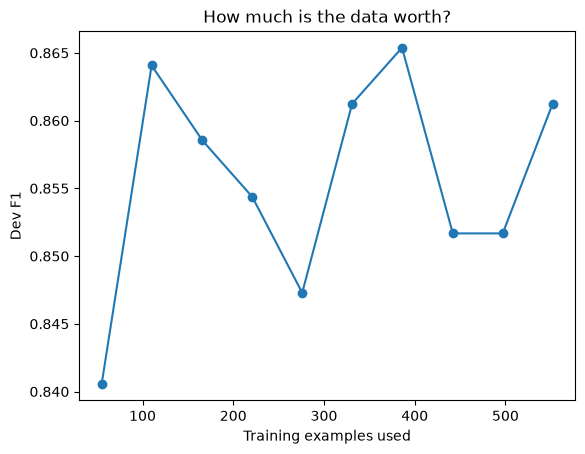

{55: 0.841, 110: 0.864, 166: 0.859, 221: 0.854, 276: 0.847, 331: 0.861, 386: 0.865, 442: 0.852, 497: 0.852, 552: 0.861}


In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

fractions = [.1, .2,.3,.4,.5,.6,.7,.8,.9,1]
sizes, scores = [], []
for frac in fractions:
    X_sub = X_train.sample(frac=frac, random_state=0)
    y_sub = y_train.loc[X_sub.index]
    model = Pipeline([('scale', StandardScaler()),
                      ('knn', svm.SVC(kernel="rbf"))]).fit(X_sub, y_sub)
    sizes.append(len(X_sub))
    scores.append(f1_score(y_dev, model.predict(X_dev)))

plt.plot(sizes, scores, marker='o')
plt.xlabel('Training examples used')
plt.ylabel('Dev F1')
plt.title('How much is the data worth?')
plt.show()
print(dict(zip(sizes, [round(s, 3) for s in scores])))